In [ ]:
# Project paths and source imports
import os
import sys
from pathlib import Path

_here = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (_here, *_here.parents) if (p / 'src').is_dir() and (p / 'models').is_dir()), _here)
os.chdir(PROJECT_ROOT)
_src_order = ['common', 'anc', 'data', 'training']
for _part in reversed(_src_order):
    _path = str(PROJECT_ROOT / 'src' / _part)
    if _path not in sys.path: sys.path.insert(0, _path)


In [ ]:
from pathlib import Path

import scipy.io as sio
import torch
import torch.nn.functional as F

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype = torch.float32
path_folder = Path.cwd() / "Pz and Sz" / "Dongyuan"

In [2]:
def fir_filter(signal, path):
    signal = signal.view(1, 1, -1)
    path = path.flip(0).view(1, 1, -1)
    y = F.conv1d(signal, path, padding=path.shape[-1] - 1)
    return y[0, 0, :len(signal.flatten())]

In [ ]:
fs = 16000
seconds = 1
noise_len = fs * seconds
num_taps = 1024
delay=50
hz = 1000
x = torch.linspace(0, seconds, fs, device=device)
noise = torch.sin(2 * torch.pi * x)
# noise = 2 * torch.rand(noise_len, device=device, dtype=dtype) - 1
pri_path, sec_path = torch.tensor(sio.loadmat(path_folder/"Primary_path.mat")["Pz1"], device=device, dtype=dtype).squeeze(1), torch.tensor(sio.loadmat(path_folder/"Secondary_path.mat")["S"], device=device, dtype=dtype).squeeze(1)
sec_path = torch.cat([torch.zeros(pri_path.argmax()-sec_path.argmax() +delay, device=device, dtype=dtype), sec_path])
d = fir_filter(noise, pri_path)
xf = fir_filter(noise, sec_path)
Xf = torch.stack([xf[n - num_taps + 1: n + 1].flip(0) for n in range(num_taps-1, noise_len)])
d_valid = d[num_taps-1:]
w = torch.linalg.lstsq(Xf, d_valid).solution
error = d - fir_filter(xf, w)
e = error.square().mean().item()
dis = d.square().mean().item()
import numpy as np

10 * np.log10(e/dis)

np.float64(-19.808912401565923)

In [16]:
filter = w.unsqueeze(0).cpu().numpy()
filter

array([[ 8.2589994e-04, -6.4465840e-04,  8.7688962e-04, ...,
        -2.2379983e-05, -6.3336811e-05, -1.1674738e-05]],
      shape=(1, 1024), dtype=float32)

In [22]:
filter = sio.loadmat("models/Pretrained_Main_Control_filter.mat")["Wc_v"]
filter = torch.tensor(filter, dtype=torch.float32).squeeze()
ws = filter.to(device)
error = d - fir_filter(xf, ws)
e = error.square().mean().item()
dis = d.square().mean().item()
import numpy as np

10 * np.log10(e/dis)

np.float64(16.325679720217963)

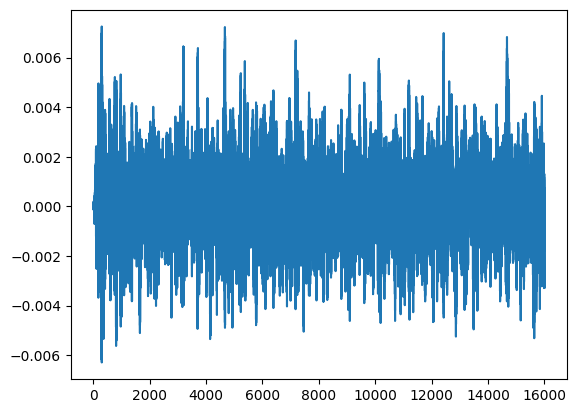

In [10]:
import matplotlib.pyplot as plt

d_array = error.cpu().numpy()
plt.plot(d_array)

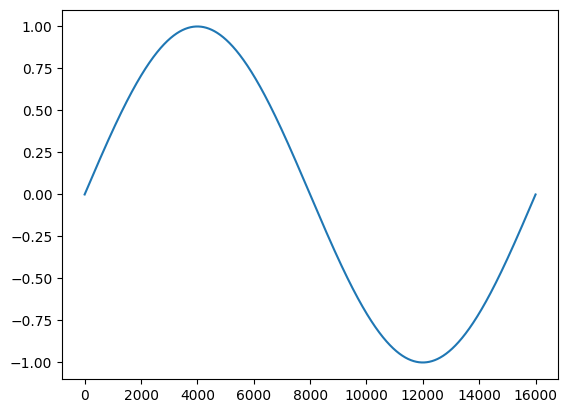

In [30]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, fs)
x = np.sin(2 * np.pi * x)
plt.plot(x)

In [35]:
x = np.array([1, 2])
y = np.array([2, 3 ,4])
np.concat([x, y])
np.abs(y).argmax()
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [40]:
import numpy as np

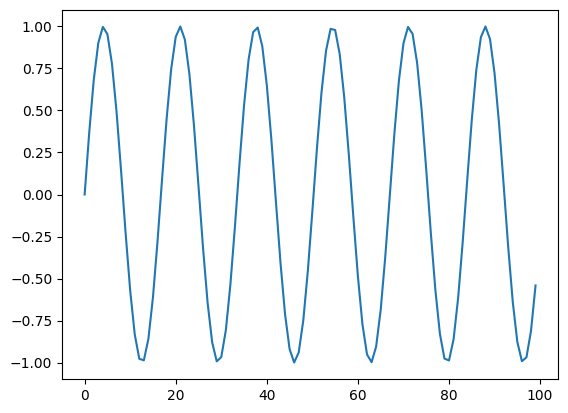

In [15]:
import matplotlib.pyplot as plt

plt.plot(noise[0:100])

In [53]:
from pathlib import Path

import numpy as np
import pyroomacoustics as pra
import scipy.io as sio
from scipy import signal

fs, seconds, numtaps, hz = 16000, 1, 1024, 1000
delay=1
path_folder = Path.cwd() / "Pz and Sz" / "Dongyuan"
noise = np.sin(2 * np.pi * hz* np.linspace(0, seconds, fs))
pri_path, sec_path = sio.loadmat(path_folder/"Primary_path.mat")["Pz1"].squeeze(), sio.loadmat(path_folder/"Secondary_path.mat")["S"].squeeze()
# sec_path = np.concat([np.zeros(np.abs(pri_path).argmax()-np.abs(sec_path).argmax() +delay), sec_path])
d = signal.lfilter(pri_path, 1, noise)
xf = signal.lfilter(sec_path, 1, noise)
nlms = pra.adaptive.NLMS(length=num_taps,mu=0.5)
for n in range(len(xf)):
    nlms.update(xf[n], d[n])
e = d - signal.lfilter(nlms.w, 1, xf)
print(10 * np.log10(np.mean(np.square(e))/np.mean(np.square(d))))

nan
